# Fase 6: Interpretacion de los clusters

Ya tenemos los 3 clusters (Fase 5). Aca los interpretamos: miramos los
promedios numericos de cada uno, las palabras que mas pesan en su texto
(TF-IDF), y les ponemos un nombre (saludable / en riesgo / abandonado,
que era la idea original del proyecto). Cerramos con las graficas finales.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = (SparkSession.builder
         .master("local[*]")
         .appName("interpretacion-gharchive")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

cols_numericas = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total", "n_actores"]

# clusters (Fase 5) y features con el tfidf (Fase 4) -- los juntamos por
# "repo" porque en Fase 5 no guardamos el tfidf, solo el cluster
clusters = spark.read.parquet("../data/processed/repos_clusterizados.parquet")
features = spark.read.parquet("../data/processed/features_repos.parquet").select("repo", "tfidf")

datos = clusters.join(features, on="repo", how="inner")
print("repos:", datos.count())
datos.groupBy("cluster").count().orderBy("cluster").show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 21:57:40 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 21:57:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 21:57:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 77696


+-------+-----+
|cluster|count|
+-------+-----+
|      0| 2189|
|      1|70295|
|      2| 5212|
+-------+-----+



## Paso 1: promedios numericos por cluster

Vemos que tan activo/colaborativo es cada cluster en promedio.

In [2]:
promedios = datos.groupBy("cluster").avg(*cols_numericas).orderBy("cluster")
promedios.show()

# lo pasamos a pandas nada mas para graficar (son solo 3 filas)
promedios_pd = promedios.toPandas()
promedios_pd.columns = ["cluster"] + cols_numericas
promedios_pd

+-------+------------------+-------------------+-------------------+--------------------+--------------------+-----------------+------------------+
|cluster|       avg(n_push)|      avg(n_issues)|          avg(n_pr)|        avg(n_watch)|         avg(n_fork)|     avg(n_total)|    avg(n_actores)|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+-----------------+------------------+
|      0|2.9191411603471904|   1.02603928734582| 1.2718136135221563|  3.8396528095020557|  0.6706258565555048|9.727272727272727|6.7779808131566925|
|      1| 3.821936126324774|0.18836332598335587|0.36346824098442276|0.010086065865282027|7.539654313962587E-4|4.384607724589231|1.1845934988263747|
|      2| 60.43879508825787| 0.5775134305448963| 0.7939370683039141|0.003453568687643...|7.674597083653108E-4|61.81446661550269|1.3720260936300843|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+--

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores
0,0,2.919141,1.026039,1.271814,3.839653,0.670626,9.727273,6.777981
1,1,3.821936,0.188363,0.363468,0.010086,0.000754,4.384608,1.184593
2,2,60.438795,0.577513,0.793937,0.003454,0.000767,61.814467,1.372026


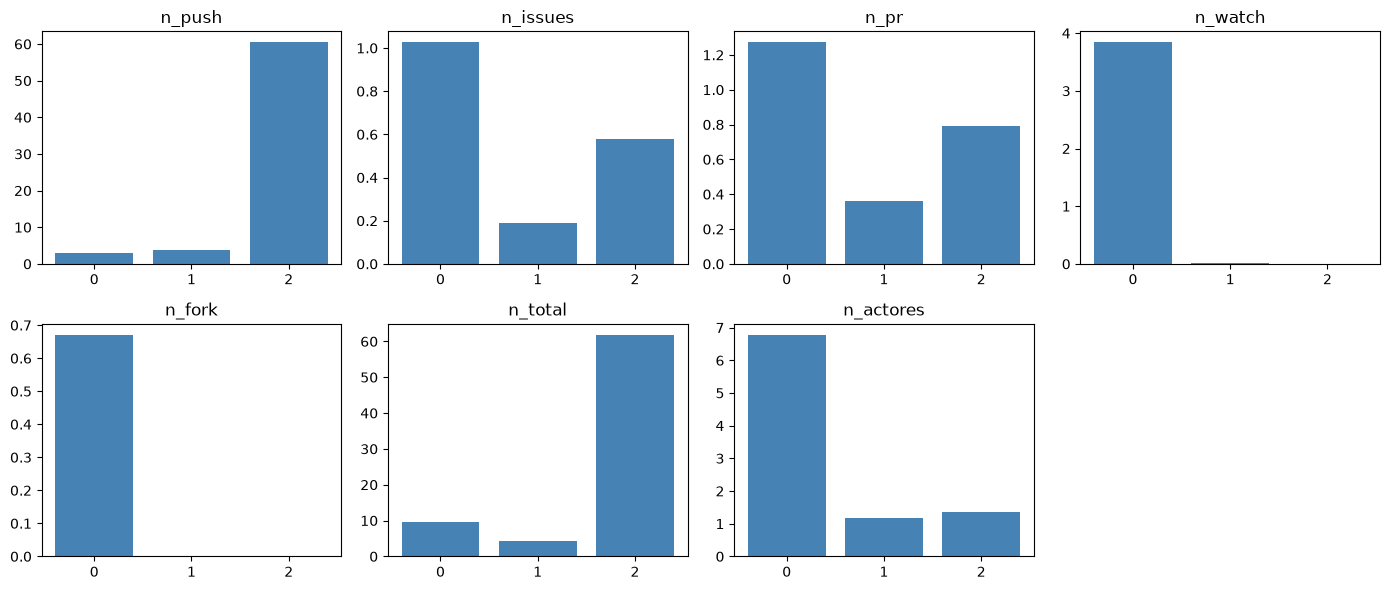

In [3]:
import matplotlib.pyplot as plt

# un mini-grafico de barras por cada feature numerico, uno por cluster
# (los graficamos separados porque las escalas son muy distintas entre si,
# ej. n_push llega a 60 y n_watch apenas a 4)
fig, ejes = plt.subplots(2, 4, figsize=(14, 6))
ejes = ejes.flatten()

for i, columna in enumerate(cols_numericas):
    ejes[i].bar(promedios_pd["cluster"].astype(str), promedios_pd[columna], color="steelblue")
    ejes[i].set_title(columna)

# el subplot 8 sobra (7 features, 8 espacios), lo escondemos
ejes[-1].axis("off")

plt.tight_layout()
plt.show()

## Paso 2: palabras top por cluster (TF-IDF)

Sacamos el vector TF-IDF promedio de cada cluster, y con el vocabulario
guardado en la Fase 4 (`models/pipeline_texto`) vemos que palabras pesan
mas en cada uno. Ojo: como vimos en Fase 4, la mayoria de los repos no
tiene texto, asi que estas palabras solo reflejan a la minoria que si tiene.

In [4]:
from pyspark.ml import PipelineModel
from pyspark.ml.stat import Summarizer

modelo_texto = PipelineModel.load("../models/pipeline_texto")
# el pipeline de texto es [tokenizer, stopwords, countvectorizer, idf],
# el vocabulario esta en la etapa 2 (countvectorizer)
vocabulario = modelo_texto.stages[2].vocabulary

# vector tfidf promedio por cluster (Summarizer hace esto de forma
# distribuida, no hay que traer todo a pandas)
resumen = Summarizer.metrics("mean")
promedio_tfidf = (datos.groupBy("cluster")
                   .agg(resumen.summary(col("tfidf")).alias("resumen"))
                   .select("cluster", "resumen.mean")
                   .collect())

TOP_N = 10
for fila in sorted(promedio_tfidf, key=lambda f: f["cluster"]):
    vector = fila["mean"].toArray()
    top_idx = vector.argsort()[::-1][:TOP_N]
    palabras_top = [vocabulario[i] for i in top_idx]
    print(f"cluster {fila['cluster']}: {palabras_top}")

cluster 0: ['com', 'github', 'https', 'odoo', 'fix', 'actions', 'tests', '0', 'add', 'commit']
cluster 1: ['update', 'com', 'github', '0', 'https', '1', 'add', 'fix', 'merge', '2']
cluster 2: ['update', '2025', '09', '23', 'add', 'license', 'commit', '08', 'creds', 'auto']


In [5]:
from pyspark.sql.functions import count, when, lit
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F

# cuantos repos de cada cluster SI tienen algo de texto util (norma del
# tfidf distinta de cero). Usamos funciones nativas de Spark (no un UDF de
# Python) porque un UDF aca choca con la version de numpy instalada.
norma_tfidf = F.aggregate(vector_to_array(col("tfidf")), lit(0.0), lambda acc, x: acc + x * x)
datos_con_flag = datos.withColumn("tiene_texto", norma_tfidf > 0)

datos_con_flag.groupBy("cluster").agg(
    count("*").alias("total"),
    count(when(col("tiene_texto"), True)).alias("con_texto"),
).orderBy("cluster").show()

+-------+-----+---------+
|cluster|total|con_texto|
+-------+-----+---------+
|      0| 2189|      822|
|      1|70295|    16467|
|      2| 5212|     1455|
+-------+-----+---------+



## Paso 3: nombrar los clusters

Con los promedios numericos (Paso 1) y las palabras top (Paso 2), les
ponemos un nombre segun la idea original del proyecto (saludable / en
riesgo / abandonado). Esto se decide leyendo los resultados de arriba, no
hay una formula — es la parte "humana" del analisis no supervisado.

In [6]:
# Nombres de cada cluster, decididos leyendo los resultados de arriba:
#
# - cluster 0 (2,189 repos): n_actores=6.8 y n_watch=3.8 en promedio (los
#   mas altos de los 3), palabras top incluyen "tests", "actions" -> repos
#   con comunidad real detras: varios colaboradores, gente que los sigue.
#
# - cluster 1 (70,295 repos, 90% de la muestra): casi siempre 1 solo actor,
#   watch/fork practicamente en cero, palabras muy genericas ("update",
#   "fix", "add") -> la cola larga tipica de GitHub: repos chicos/personales
#   con poco o nada de mantenimiento visible.
#
# - cluster 2 (5,212 repos): n_push altisimo (60 en promedio) pero solo 1.4
#   actores y casi cero watch/fork. Las palabras top tienen fechas ("2025",
#   "09", "23") y palabras como "auto", "creds" -> pinta a commits
#   automatizados/programados, no actividad humana organica. Mucho volumen
#   pero fragil: si se rompe el script, nadie mas lo nota.

nombres_cluster = {
    0: "Saludable / colaborativo",
    1: "Baja actividad / cola larga",
    2: "Automatizado intensivo / riesgo",
}

resumen_final = promedios_pd.copy()
resumen_final["nombre"] = resumen_final["cluster"].map(nombres_cluster)
resumen_final

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores,nombre
0,0,2.919141,1.026039,1.271814,3.839653,0.670626,9.727273,6.777981,Saludable / colaborativo
1,1,3.821936,0.188363,0.363468,0.010086,0.000754,4.384608,1.184593,Baja actividad / cola larga
2,2,60.438795,0.577513,0.793937,0.003454,0.000767,61.814467,1.372026,Automatizado intensivo / riesgo


In [7]:
# unos ejemplos reales de cada cluster, para hacerlo mas concreto en la sustentacion
for c in [0, 1, 2]:
    print(f"--- cluster {c} ({nombres_cluster[c]}) ---")
    datos.filter(col("cluster") == c).select("repo", *cols_numericas).show(5, truncate=False)

--- cluster 0 (Saludable / colaborativo) ---
+----------------------------------+------+--------+----+-------+------+-------+---------+
|repo                              |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|
+----------------------------------+------+--------+----+-------+------+-------+---------+
|AbdullahGhanem/quran-database     |0     |0       |0   |14     |0     |14     |14       |
|All-Hands-AI/OpenHands            |9     |0       |3   |2      |0     |14     |5        |
|AndyMik90/Auto-Claude             |3     |3       |13  |1      |0     |20     |4        |
|ChromeDevTools/chrome-devtools-mcp|6     |1       |4   |27     |1     |39     |29       |
|ComposioHQ/awesome-claude-skills  |0     |0       |1   |13     |1     |15     |15       |
+----------------------------------+------+--------+----+-------+------+-------+---------+
only showing top 5 rows
--- cluster 1 (Baja actividad / cola larga) ---


+---------------------------------+------+--------+----+-------+------+-------+---------+
|repo                             |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|
+---------------------------------+------+--------+----+-------+------+-------+---------+
|0nenessPC/darer-journey-app      |3     |0       |0   |0      |0     |3      |1        |
|0xKhan-web3/0xKhan-web3.github.io|4     |0       |0   |0      |0     |4      |1        |
|0xb-s/egui_plot                  |4     |0       |0   |0      |0     |4      |1        |
|0xpolarzero/electron-agent-tools |3     |0       |0   |0      |0     |3      |1        |
|1337B/rewine                     |4     |0       |1   |0      |0     |5      |1        |
+---------------------------------+------+--------+----+-------+------+-------+---------+
only showing top 5 rows
--- cluster 2 (Automatizado intensivo / riesgo) ---
+-----------------------------------+------+--------+----+-------+------+-------+---------+
|repo                 

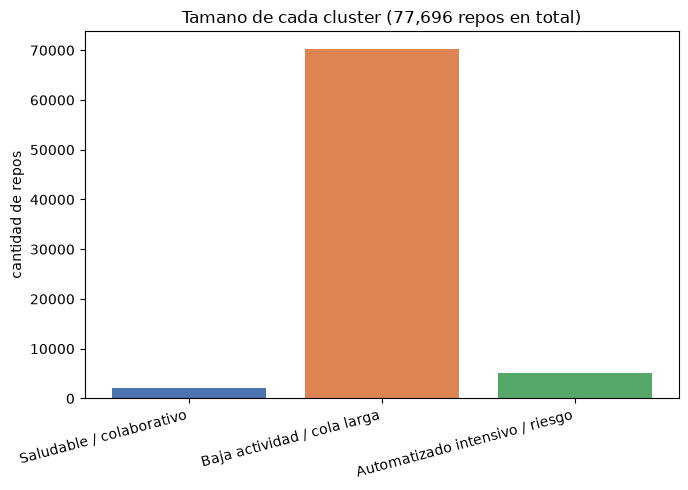

In [8]:
# grafico final: tamano de cada cluster, con su nombre
tamanos_pd = datos.groupBy("cluster").count().orderBy("cluster").toPandas()
tamanos_pd["nombre"] = tamanos_pd["cluster"].map(nombres_cluster)

fig, ax = plt.subplots(figsize=(7, 5))
colores = ["#4C72B0", "#DD8452", "#55A868"]
ax.bar(tamanos_pd["nombre"], tamanos_pd["count"], color=colores)
ax.set_ylabel("cantidad de repos")
ax.set_title(f"Tamano de cada cluster ({tamanos_pd['count'].sum():,} repos en total)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Conclusiones

De 536,381 repos vistos en 12 horas dispersas de GH Archive (ago 2025 -
jul 2026), y quedandonos con los 77,696 que tuvieron al menos 3 eventos,
KMeans (k=3) encontro 3 grupos de comportamiento bien distintos:

1. **Saludable / colaborativo** (2,189 repos, 2.8%): varios colaboradores
   y gente que los sigue (watch). El grupo mas chico, pero el que mas se
   parece a un proyecto open source "sano" en el sentido tradicional.
2. **Baja actividad / cola larga** (70,295 repos, 90.5%): casi siempre un
   solo actor, sin watch ni fork. La inmensa mayoria de GitHub: repos
   chicos, personales o de practica, sin senales de comunidad.
3. **Automatizado intensivo / riesgo** (5,212 repos, 6.7%): muchisimos
   push (60 en promedio) pero de una sola persona, y palabras de texto que
   sugieren commits programados (fechas, "auto"). Mucho volumen, pero
   fragil: depende de una sola persona o script.

**Limitaciones a tener en cuenta (importantes para la sustentacion):**
- La muestra es de 12 horas puntuales, no series de tiempo por repo — los
  numeros reflejan "que tanto se vio ese repo en esa hora", no su
  historia completa.
- El texto (TF-IDF) solo estaba disponible para una minoria de los
  repos (ver Fase 4) — los clusters se apoyan mas en los conteos
  numericos que en el texto.
- "Saludable/riesgo/abandonado" es una interpretacion nuestra de los
  patrones que encontro KMeans, no una etiqueta que vino en los datos
  (el proyecto es no supervisado, no hay "respuesta correcta").